In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor

from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.metrics import classification_report,precision_score
from sklearn.metrics import recall_score,f1_score

In [2]:
df = pd.read_csv("titanic.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [6]:
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [7]:
le = LabelEncoder()

In [9]:
df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [11]:
df = df.drop(columns=["pclass", "name", "ticket", "cabin"])

In [13]:
X = df.drop("survived", axis=1)
y = df["survived"]

In [14]:
print(X.dtypes)

sex           int64
age         float64
sibsp         int64
parch         int64
fare        float64
embarked      int64
dtype: object


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = DecisionTreeClassifier(random_state=42)

In [17]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
y_pred = model.predict(X_test)

In [19]:
# Train Model
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("Accuracy :", accuracy_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Confusion Matrix
[[122  22]
 [ 41  77]]
Precision : 0.7777777777777778
Recall : 0.652542372881356
Accuracy : 0.7595419847328244
F1 Score : 0.7096774193548387
              precision    recall  f1-score   support

           0       0.75      0.85      0.79       144
           1       0.78      0.65      0.71       118

    accuracy                           0.76       262
   macro avg       0.76      0.75      0.75       262
weighted avg       0.76      0.76      0.76       262



In [21]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion="gini",          # "gini" or "entropy"
    splitter="best",           # "best" or "random"
    max_depth=5,               # Maximum depth of tree
    min_samples_split=2,       # Minimum samples required to split
    min_samples_leaf=1,        # Minimum samples in a leaf node
    max_features=None,         # Number of features to consider
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
model = DecisionTreeRegressor(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


mae= mean_absolute_error(y_test, y_pred)
print(f"MAE :{mae}")

mse = mean_squared_error(y_test, y_pred)
print(f"MSE :{mse}")

rmse = np.sqrt(mse)
print(f"RMSE :{rmse}")


print("R2 Score :",r2_score(y_test, y_pred))

MAE :0.24732824427480915
MSE :0.2340966921119593
RMSE :0.48383539774592693
R2 Score : 0.05430006277463939


In [24]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

[Text(0.5, 0.9166666666666666, 'x[0] <= 0.5\nsquared_error = 0.232\nsamples = 1047\nvalue = 0.365'),
 Text(0.26973684210526316, 0.75, 'x[4] <= 48.2\nsquared_error = 0.204\nsamples = 370\nvalue = 0.714'),
 Text(0.3848684210526316, 0.8333333333333333, 'True  '),
 Text(0.17105263157894737, 0.5833333333333334, 'x[2] <= 2.5\nsquared_error = 0.234\nsamples = 269\nvalue = 0.628'),
 Text(0.10526315789473684, 0.4166666666666667, 'x[4] <= 15.646\nsquared_error = 0.227\nsamples = 253\nvalue = 0.652'),
 Text(0.05263157894736842, 0.25, 'x[4] <= 7.267\nsquared_error = 0.246\nsamples = 137\nvalue = 0.562'),
 Text(0.02631578947368421, 0.08333333333333333, 'squared_error = 0.0\nsamples = 8\nvalue = 1.0'),
 Text(0.07894736842105263, 0.08333333333333333, 'squared_error = 0.249\nsamples = 129\nvalue = 0.535'),
 Text(0.15789473684210525, 0.25, 'x[3] <= 3.5\nsquared_error = 0.183\nsamples = 116\nvalue = 0.759'),
 Text(0.13157894736842105, 0.08333333333333333, 'squared_error = 0.157\nsamples = 108\nvalue = 0

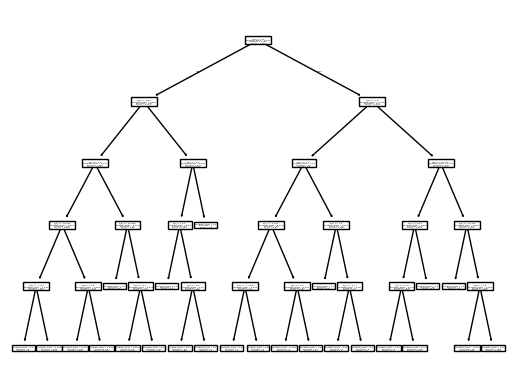

In [25]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    criterion="squared_error",   # "squared_error", "friedman_mse", "absolute_error", "poisson"
    splitter="best",             # "best" or "random"
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42
)

clf=model.fit(X_train, y_train)

y_pred = model.predict(X_test)
tree.plot_tree(clf)